### Library Imports and JAX Backend Selection

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries and set JAX backend
import os
# os.environ['JAX_PLATFORMS']="cuda" # select cpu instead if no gpu is available
os.environ['JAX_PLATFORMS']="cpu"

from flax import nnx
import jax
import jax.numpy as jnp
import optax
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
# Set training and model restoration flags
overwrite_model = False
restore_model = True  # Use pretrained model if available
train_model = False  # Set to True to train from scratch

In [4]:
# Specify the checkpoint directory for saving/restoring models
import orbax.checkpoint as ocp
checkpoint_dir = f"{os.getcwd()}/checkpoints/diffusion_2d_example"

import os
os.makedirs(checkpoint_dir, exist_ok=True)

if overwrite_model:
    checkpoint_dir = ocp.test_utils.erase_and_create_empty(checkpoint_dir)

## 2. Data Generation

We generate a synthetic 2D dataset using JAX. This section defines the data generation functions and visualizes the data distribution.

In [5]:
# Define a function to generate 2D box data using JAX
import jax
import jax.numpy as jnp
from jax import random
from functools import partial
import grain

@partial(jax.jit, static_argnums=[1])  # type: ignore
def make_boxes_jax(key, batch_size: int = 200):
    """
    Generates a batch of 2D data points similar to the original PyTorch function
    using JAX.

    Args:
        key: A JAX PRNG key for random number generation.
        batch_size: The number of data points to generate.

    Returns:
        A JAX array of shape (batch_size, 2) with generated data,
        with dtype float32.
    """
    # Split the key for different random operations
    keys = jax.random.split(key, 3)
    x1 = jax.random.uniform(keys[0],batch_size) * 4 - 2
    x2_ = jax.random.uniform(keys[1],batch_size) - jax.random.randint(keys[2], batch_size, 0,2) * 2
    x2 = x2_ + (jnp.floor(x1) % 2)

    data = 1.0 * jnp.concatenate([x1[:, None], x2[:, None]], axis=1) / 0.45

    return data

/lhome/ific/a/aamerio/miniforge3/envs/gensbi/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at grain/proto/execution_summary.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(


In [6]:
# # Infinite data generator for training batches
# @partial(jax.jit, static_argnums=[1])  # type: ignore
# def inf_train_gen(key, batch_size: int = 200):
#     x = make_boxes_jax(key, batch_size)

#     return x

batch_size = 8

data = make_boxes_jax(jax.random.PRNGKey(0), 500_000)

train_dataset_grain = (
    grain.MapDataset.source(np.array(data)[...,None])
    .shuffle(42)
    .repeat()
    .to_iter_dataset()
)


train_dataset_batched = train_dataset_grain.batch(batch_size)

train_iter = iter(train_dataset_batched)

data_val = make_boxes_jax(jax.random.PRNGKey(1), 1000)

val_dataset_batched = (
    grain.MapDataset.source(np.array(data_val)[...,None])
    .shuffle(42)
    .repeat()
    .to_iter_dataset()
    .batch(512)
)

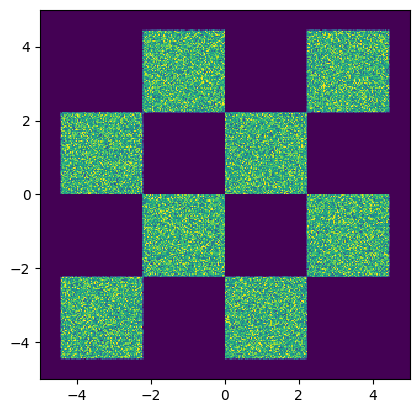

In [7]:
# Visualize the generated data distribution
samples = np.array(data)

H=plt.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)))
cmin = 0.0
cmax = jnp.quantile(jnp.array(H[0]), 0.99).item()
norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

_ = plt.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)), norm=norm, cmap="viridis")

# set equal ratio of axes
plt.gca().set_aspect('equal', adjustable='box')


plt.show()

## 3. Model and Loss Definition

We define the velocity field model (an MLP), the loss function, and the optimizer for training the score-matching model.

In [8]:
# Import diffusion components and utilities
from gensbi.recipes import UnconditionalDiffusionPipeline

In [9]:
# Define the MLP velocity field model
class MLP(nnx.Module):
    def __init__(self, input_dim: int = 2, hidden_dim: int = 128, *, rngs: nnx.Rngs):

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        din = input_dim + 1

        self.linear1 = nnx.Linear(din, self.hidden_dim, rngs=rngs)
        self.linear2 = nnx.Linear(self.hidden_dim, self.hidden_dim, rngs=rngs)
        self.linear3 = nnx.Linear(self.hidden_dim, self.hidden_dim, rngs=rngs)
        self.linear4 = nnx.Linear(self.hidden_dim, self.hidden_dim, rngs=rngs)
        self.linear5 = nnx.Linear(self.hidden_dim, self.input_dim, rngs=rngs)

    def __call__(self, t: jax.Array, obs: jax.Array,  **kwargs):
        assert obs.ndim == 3, f"Input obs must have shape (batch_size, input_dim, 1), got {obs.shape}"

        # we need to massage the data a bit to make it compatible with the pipeline format
        t = jnp.atleast_1d(t)
        x = jnp.squeeze(obs, axis=-1)


        if t.ndim<2:
            t = t[..., None]

        if t.ndim==3:
            t = t[...,0]

        t = jnp.broadcast_to(t, (x.shape[0], t.shape[-1]))

        # now everything whould have the right dimension, we can proceed

        h = jnp.concatenate([x, t], axis=-1)

        x = self.linear1(h)
        x = jax.nn.gelu(x)

        x = self.linear2(x)
        x = jax.nn.gelu(x)

        x = self.linear3(x)
        x = jax.nn.gelu(x)

        x = self.linear4(x)
        x = jax.nn.gelu(x)

        x = self.linear5(x)

        return x[...,None]

In [10]:
# # Initialize the velocity field model
# hidden_dim = 512

# # velocity field model init
# model = MLP(input_dim=2, hidden_dim=hidden_dim, rngs=nnx.Rngs(0))

# training_config = UnconditionalDiffusionPipeline.get_default_training_config()
# training_config["checkpoint_dir"] = checkpoint_dir
# training_config["nsteps"] = 30_000


# pipeline = UnconditionalDiffusionPipeline(model,
#     train_dataset_batched,
#     val_dataset_batched,
#     2,
#     training_config=training_config)

In [11]:
# Restore the model from checkpoint if requested
# if restore_model:
#     pipeline.restore_model()

# Test the parameters of the equation

In [ ]:
from gensbi.diffusion.path import EDMPath
from gensbi.diffusion.path.scheduler import VEEdmScheduler, VPEdmScheduler
from sde import VPSDE, VESDE

In [13]:
batch = next(train_iter)

## VE test

In [ ]:
sigma_min = 0.001
sigma_max = 15.
scheduler = VEEdmScheduler(sigma_min, sigma_max)
path = EDMPath(scheduler=scheduler)
path.scheduler.sigma_min, path.scheduler.sigma_max

f_edm = scheduler.f
g_edm = scheduler.g

/lustre/ific.uv.es/ml/ific088/github/GenSBI/src/gensbi/diffusion/path/edm_path.py:70: UserWarning: EDM-VP and EDM-VE paths are currently not recommended for use.
  warnings.warn(


In [15]:
x0 = batch
u = jnp.atleast_1d(0.2)
t = scheduler.time_schedule(u)
sigma = scheduler.sigma(t)
key = jax.random.PRNGKey(0)

x = path.sample(key, x0, sigma).x_t

In [16]:
f_val = f_edm(x, u)
g_val = g_edm(x, u)

In [17]:
sde = VESDE(sigma_min=sigma_min, sigma_max=sigma_max, dim=2)

In [18]:
jnp.isclose(sde.diffusion(x, u), g_val)

Array([ True], dtype=bool)

In [19]:
jnp.all(jnp.isclose(sde.drift(x, u), f_val))

Array(True, dtype=bool)

In [20]:
sde.sigma(0.2), jnp.sqrt(scheduler.time_schedule(0.2))

(Array(0.00684255, dtype=float32, weak_type=True),
 Array(0.00684255, dtype=float32, weak_type=True))

## VP

In [ ]:
beta_min = 0.001
beta_max = 3.0
e_s=1e-3
e_t=1e-5
M=1000
scheduler = VPEdmScheduler(beta_min, beta_max, e_s,e_t,M)
path = EDMPath(scheduler=scheduler)
path.scheduler.beta_min, path.scheduler.beta_max

f_edm = scheduler.f
g_edm = scheduler.g

In [22]:
t = scheduler.time_schedule(u)
sigma = scheduler.sigma(t)
key = jax.random.PRNGKey(0)

x = path.sample(key, x0, sigma).x_t

In [23]:
f_val = f_edm(x, u)
g_val = g_edm(x, u)

In [24]:
sde = VPSDE(dim=2, beta_min=beta_min, beta_max=beta_max)

In [25]:
jnp.all(jnp.isclose(sde.drift(x, u), f_val))

Array(True, dtype=bool)

In [26]:
jnp.isclose(sde.diffusion(x, u), g_val)

Array([ True], dtype=bool)